In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_raw = pd.read_csv('../data_raw/StudentsPerformance.csv')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [3]:
df_raw['race/ethnicity'] = df_raw['race/ethnicity'].astype('category')
df_raw['parental level of education'] = df_raw['parental level of education'].astype('category')
df_raw['test preparation course'] = df_raw['test preparation course'].astype('category')
df_raw['gender'] = df_raw['gender'].astype('category')
df_raw['lunch'] = df_raw['lunch'].astype('category')

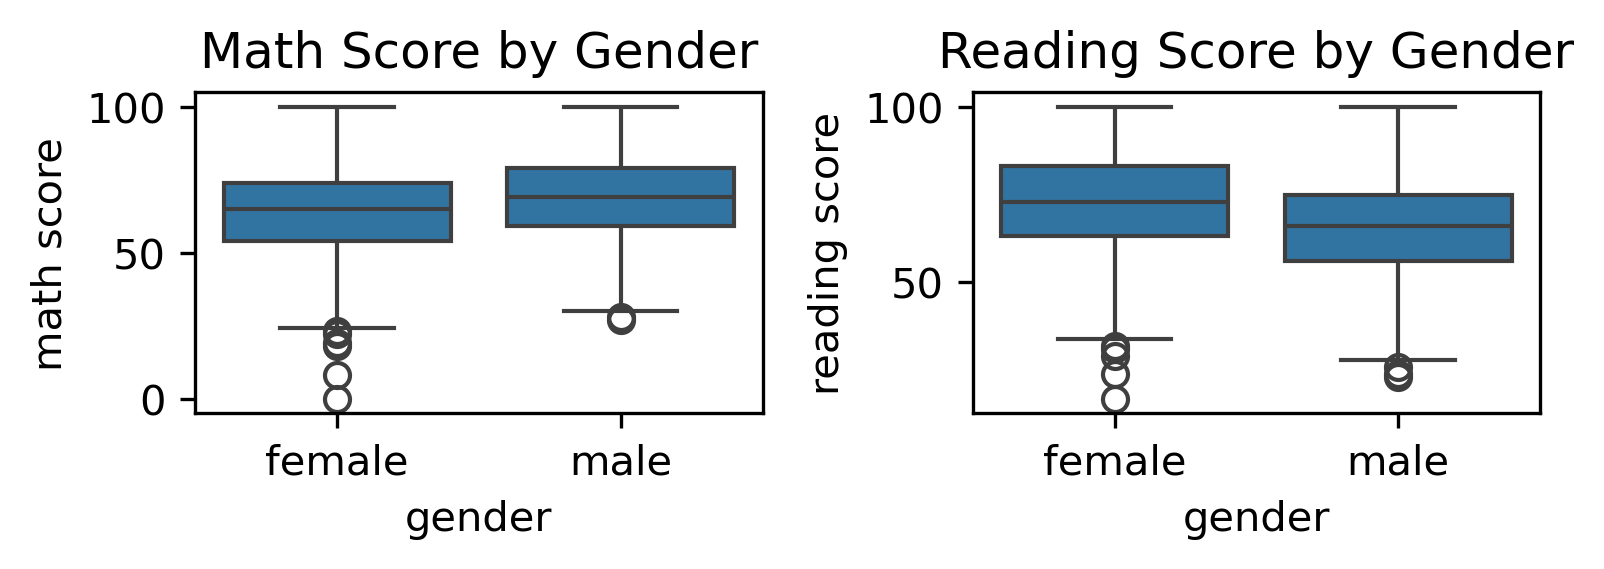

In [11]:
width_in = 1600 / 300  # doubled width to fit two panels comfortably
height_in = 600 / 300

fig, axes = plt.subplots(1, 2, figsize=(width_in, height_in), dpi=300)

sns.boxplot(data=df_raw, x="gender", y="math score", ax=axes[0])
axes[0].set_title("Math Score by Gender")

sns.boxplot(data=df_raw, x="gender", y="reading score", ax=axes[1])
axes[1].set_title("Reading Score by Gender")

plt.tight_layout()
plt.show()

Are there gender differences in math vs reading?

There is a considerable difference in the minimum score for males in reading compared to males in math. The same goes for the median and IQR. More interesting is the spread/size of the IQR is tighter in the math scores, meaning the middle 50% is more centered and close values for males in math whereas the reading middle 50% is more distributed.

Females have very similar lower end scoring characteristics on both test, with the exception of the 1st Quartile being lower in reading than in math. However unlike the male reading scores, the female reading scores IQR is higher that the female math score IQR. The reading scores for females are also more distributed like the males.

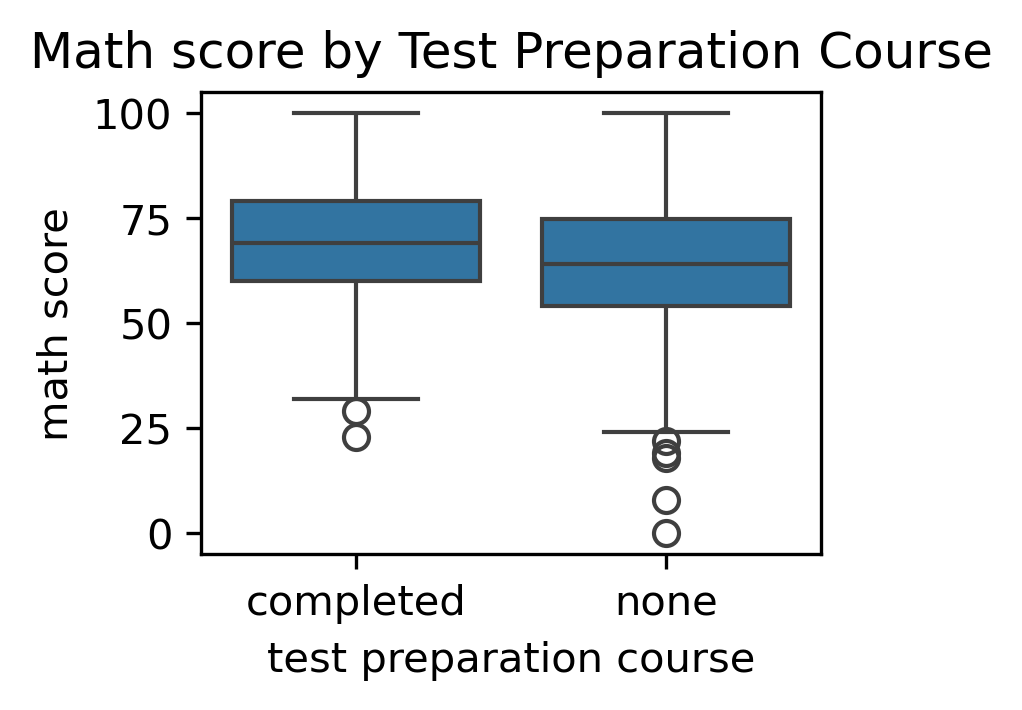

In [5]:
width_in = 800 / 300
height_in = 600 / 300

plt.figure(figsize=(width_in, height_in), dpi = 300)
sns.boxplot(data=df_raw, x="test preparation course", y="math score")
plt.title("Math score by Test Preparation Course")
plt.show()

Do students who completed test prep score higher in math?

Yes, the middle 50% or IQR are scoring a noticeable amount higher in math when completing the test preparation course. Those student also have a higher 1st Quartile, and only two outliers on the lower side of the box and whisker. Both of those outliers still being higher than all of the more frequen outliers of the no test preparation course.

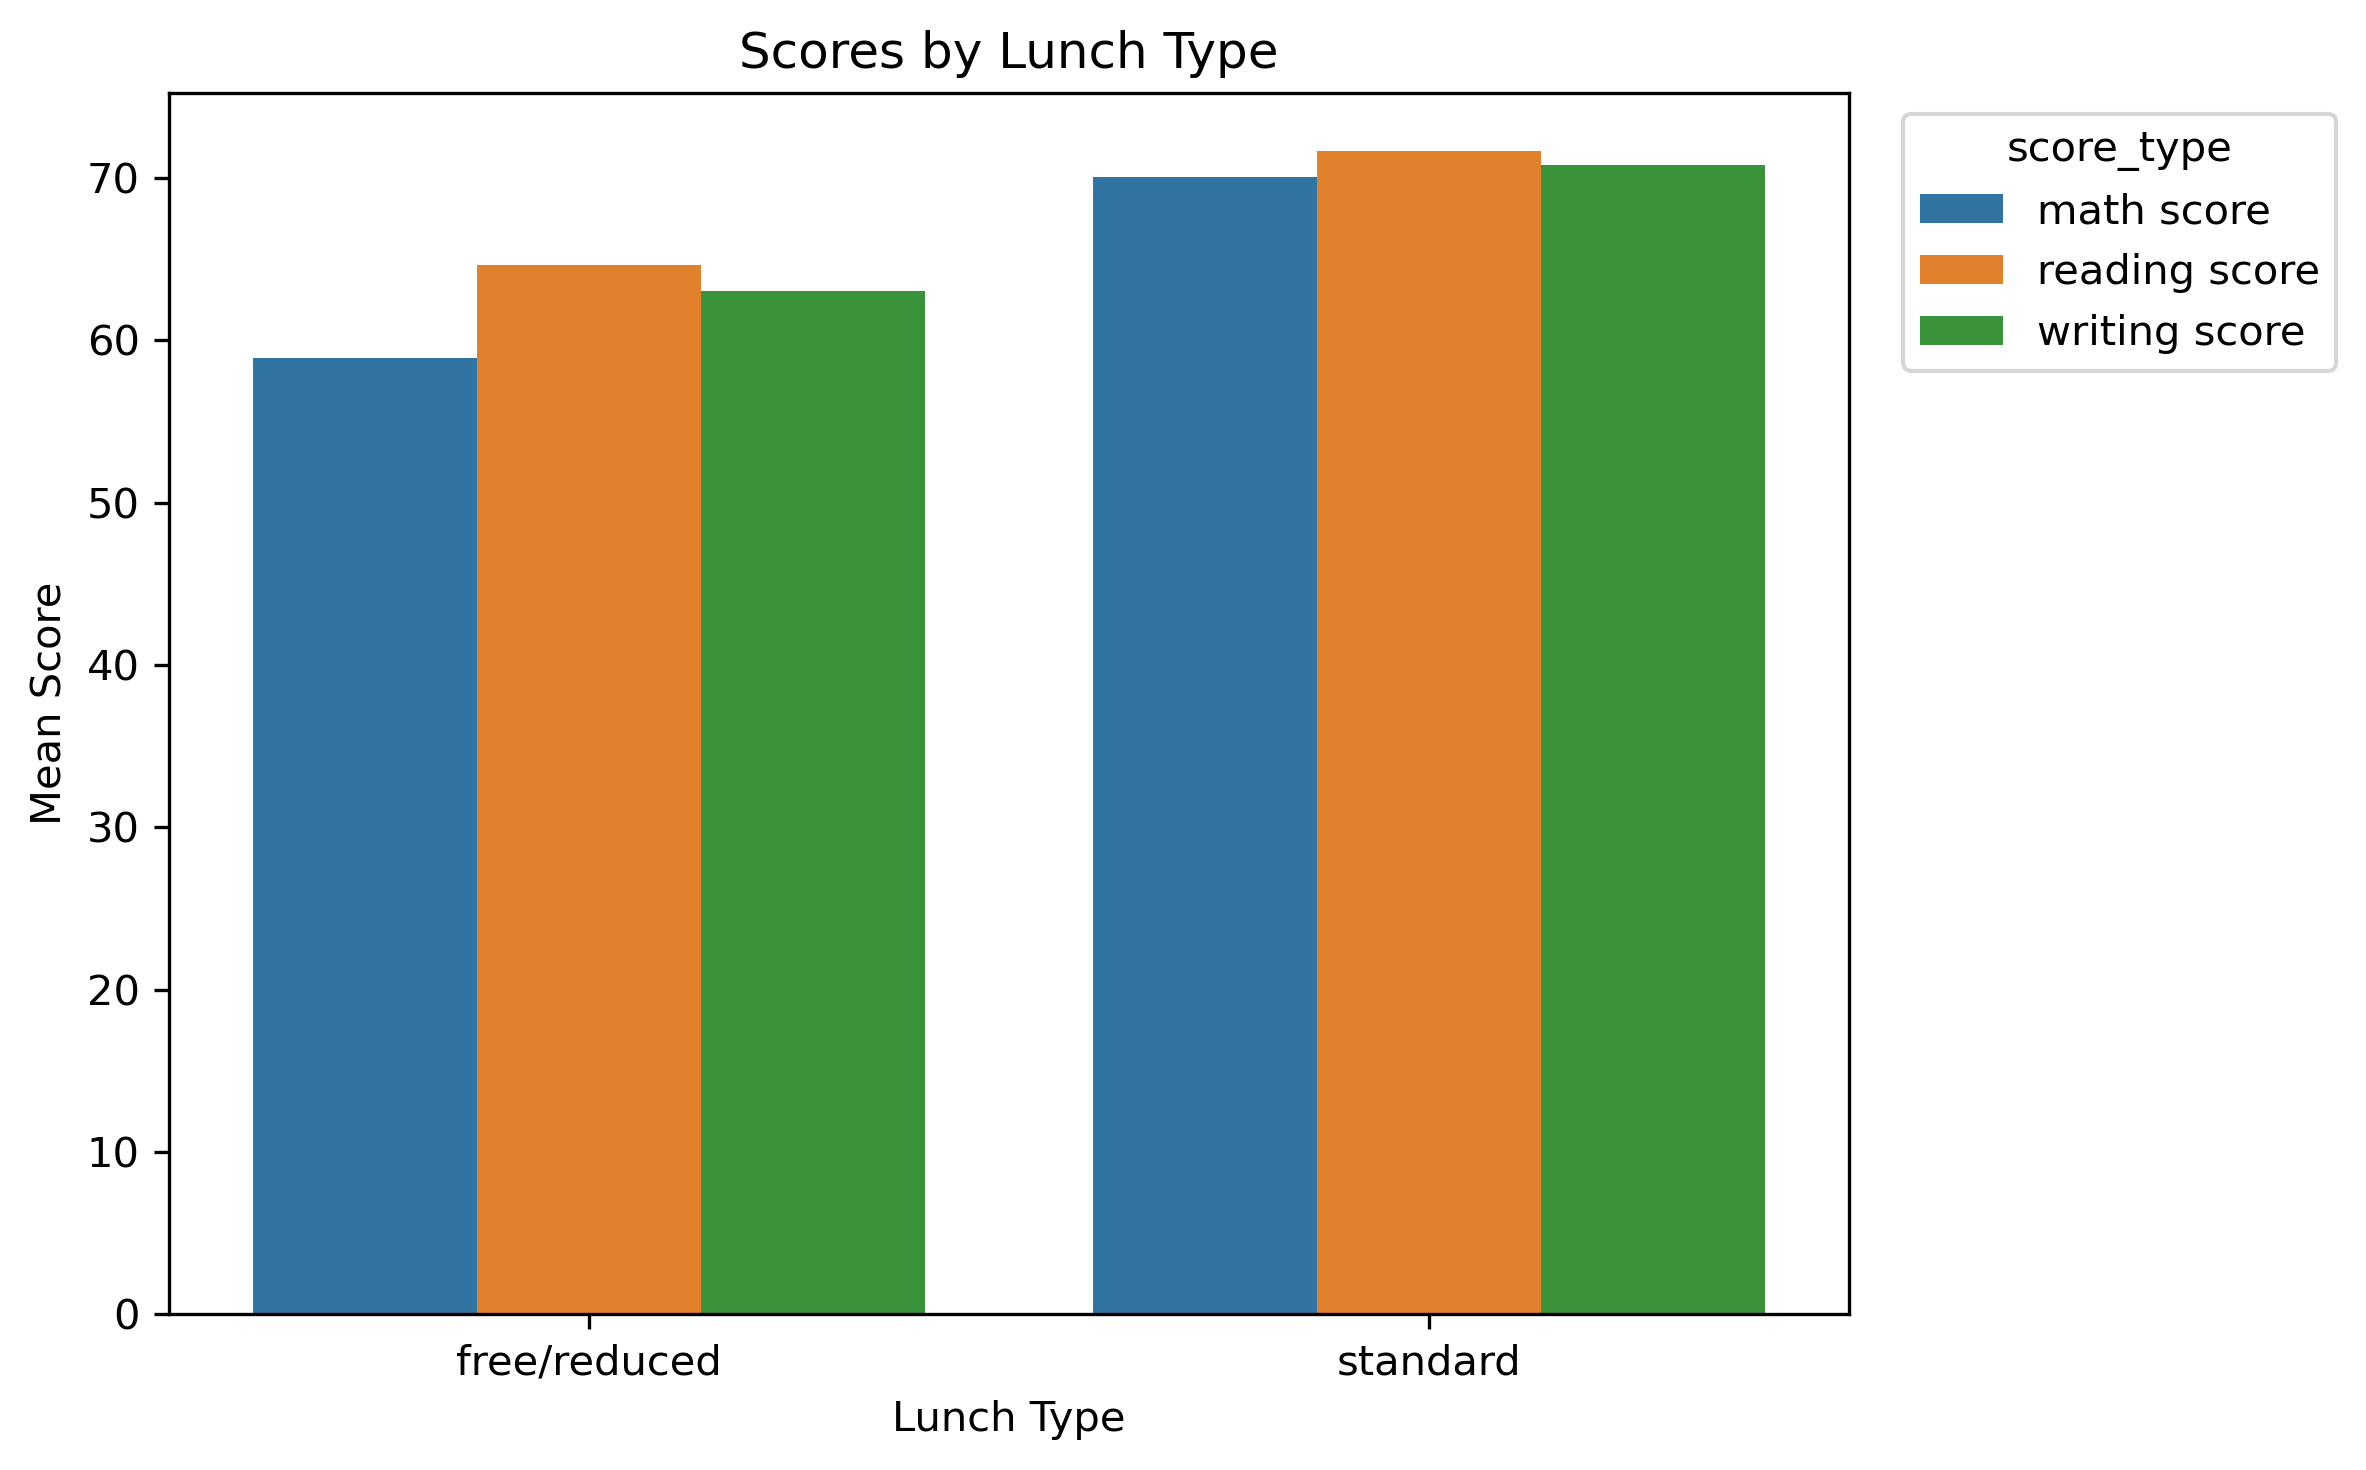

In [6]:
width_in = 800 / 300
height_in = 600 / 300

df_raw_long = df_raw.melt(
    id_vars="lunch",                                          # column(s) to keep as-is, repeated for each new row
    value_vars=["math score", "reading score", "writing score"],  # columns to unpivot/stack
    var_name="score_type",                                    # name for the new "which column was this" column
    value_name="score"                                        # name for the new "value" column
)

plt.figure(figsize=(8, 5), dpi = 300)
sns.barplot(data=df_raw_long, x="lunch", y="score", hue="score_type", errorbar=None)
plt.title("Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Mean Score")
plt.legend(title="score_type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("../reports/figures/scores_by_lunch.png", dpi=300, bbox_inches="tight")
plt.show()

Does lunch type (standard vs free/reduced) relate to outcomes?

Yes, lunch type standard versus free reduced relates to outcomes strongly in this data set. Across all three score types, standard lunch type scores higher as a mean score than the free and reduced lunch type. From the visualization, math seems to be the most impacted by lunch type. However, it is inconclusive from the visualization and it appears maybe writing is the most affected. It also appears the impact can be between 8 to 10% of mean score based on which lunch type.

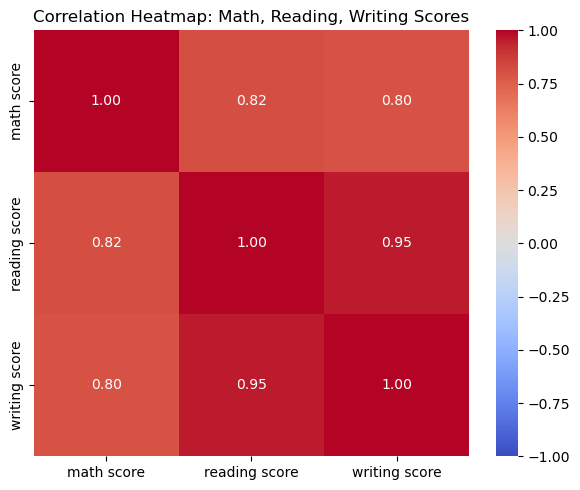

In [7]:
corr = df_raw[["math score", "reading score", "writing score"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Math, Reading, Writing Scores")
plt.tight_layout()
plt.show()

How strongly do the three subjects move together?

The three subjects move together particularly strongly, as all are above 80 in their correlation pairwise. Specifically, reading score and writing score are the strongest correlation almost at unity. And then math and reading, as well as math and writing, are both almost negligible in their individual correlations, being math and reading at 82 and math and writing at 80. I would expect strong  behaviors and outputs in modeling from the pairwise relations of all three subjects.

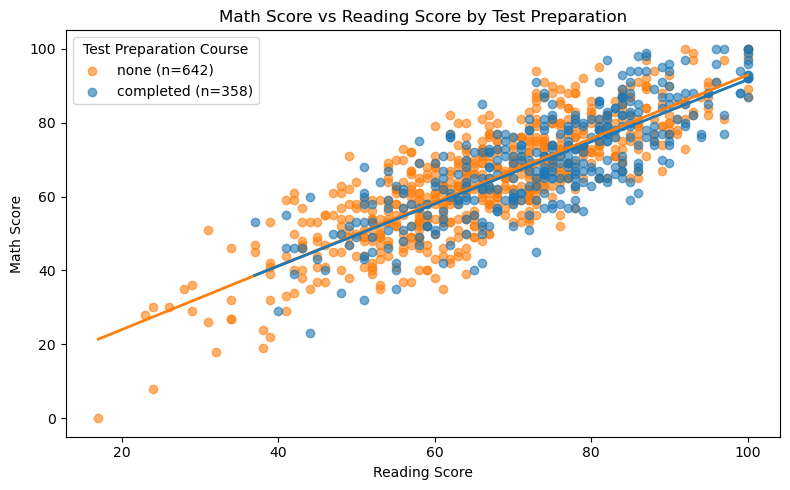

In [10]:
groups = df_raw["test preparation course"].unique()
colors = {"completed": "tab:blue", "none": "tab:orange"}

fig, ax = plt.subplots(figsize=(8, 5))

for grp in groups:
    subset = df_raw[df_raw["test preparation course"] == grp]
    n = len(subset)

    ax.scatter(subset["reading score"], subset["math score"],
               color=colors[grp], alpha=0.6, label=f"{grp} (n={n})")

    slope, intercept = np.polyfit(subset["reading score"], subset["math score"], 1)

    x_vals = np.linspace(subset["reading score"].min(), subset["reading score"].max(), 100)
    y_vals = slope * x_vals + intercept
    ax.plot(x_vals, y_vals, color=colors[grp], linewidth=2)

ax.set_xlabel("Reading Score")
ax.set_ylabel("Math Score")
ax.set_title("Math Score vs Reading Score by Test Preparation")
ax.legend(title="Test Preparation Course")

plt.tight_layout()
plt.savefig("../reports/figures/math_vs_reading_by_prep.png", dpi=300)
plt.show()

How strongly are math and reading scores associated, and do students who
completed the test‑preparation course have a different slope in the math–reading
relationship than those who did not?

Math and reading scores are very strongly correlated as the slope is very positive. Students who completed the test preparation course have almost an identical slope in both the math and reading related, and both the math score and reading score. than those who did not. It appears or shows that the underlying relationship between the two subjects is the same regardless of whether a student prepped.